# Module 2 — Customer Analytics

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import json
import os

In [2]:
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

# Style constants
NAVY   = '#1E3A5F'
BLUE   = '#2563EB'
AMBER  = '#F59E0B'
SLATE  = '#718096'
PALETTE = [NAVY, BLUE, AMBER, SLATE, '#059669', '#DC2626']

plt.rcParams['figure.dpi'] = 100
FIG_SIZE = (12, 6.75)

EXPORT_DIR = '../exports/module2'
os.makedirs(EXPORT_DIR, exist_ok=True)

def save_json(obj, name):
    path = f'{EXPORT_DIR}/{name}'
    with open(path, 'w') as f:
        json.dump(obj, f, indent=2, default=str)
    print(f'Saved {path}')

def save_fig(fig, name):
    path = f'{EXPORT_DIR}/{name}'
    fig.savefig(path, dpi=300, bbox_inches='tight')
    print(f'Saved {path}')

In [3]:
df = pd.read_csv(r'C:\Users\META\Documents\Desktop\master_sales.csv', low_memory=False)
df['transaction_date'] = pd.to_datetime(df['transaction_date'])
df['customer_since'] = pd.to_datetime(df['customer_since'])
df.shape

(50000, 40)

In [4]:
df[['customer_id','transaction_date','net_revenue','segment','customer_since']].isnull().sum()

customer_id         0
transaction_date    0
net_revenue         0
segment             0
customer_since      0
dtype: int64

## RFM Analysis

The dataset already has a business-assigned `segment` column
(Premium / Standard / Budget / New). That is a *label*, not an *analysis*. RFM
lets us measure actual customer behaviour independently and then check whether
it agrees with the business label.

**Definitions used:**
- **Recency** — days between each customer's last purchase and a fixed snapshot
  date (one day after the last transaction in the data).
- **Frequency** — number of transactions per customer.
- **Monetary** — total net revenue per customer.

In [5]:
snapshot_date = df['transaction_date'].max() + pd.Timedelta(days=1)

rfm = df.groupby('customer_id').agg(
    last_purchase=('transaction_date', 'max'),
    frequency=('transaction_id', 'count'),
    monetary=('net_revenue', 'sum'),
).reset_index()

rfm['recency'] = (snapshot_date - rfm['last_purchase']).dt.days

print(f"Customers: {len(rfm):,}")
rfm[['recency', 'frequency', 'monetary']].describe().round(1)

Customers: 2,000


,recency,frequency,monetary
count,"2,000.00","2,000.00","2,000.00"
mean,31.80,25.00,"9,056.90"
std,51.20,5.90,"3,339.10"
min,1.00,6.00,897.70
25%,6.00,21.00,"6,596.20"
50%,16.00,25.00,"8,781.00"
75%,34.00,29.00,"10,935.40"
max,388.00,44.00,"23,400.90"


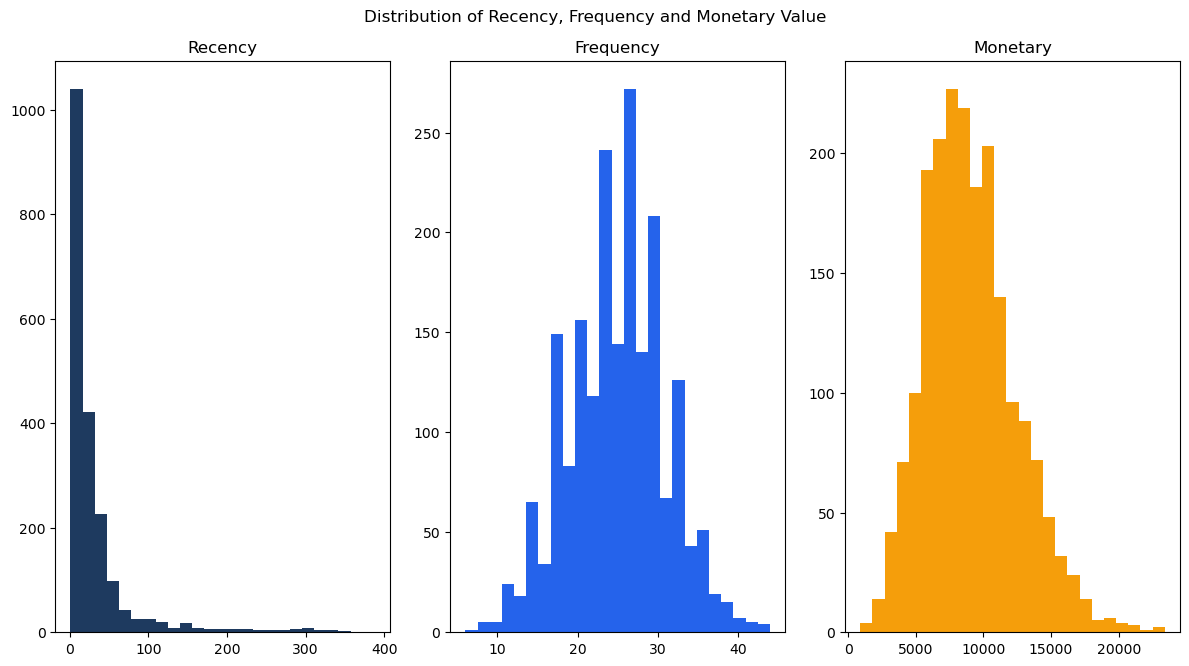

Saved ../exports/module2/rfm_distributions.png


In [6]:
fig, axes = plt.subplots(1, 3, figsize=FIG_SIZE)
for ax, col, color in zip(axes, ['recency', 'frequency', 'monetary'], [NAVY, BLUE, AMBER]):
    ax.hist(rfm[col], bins=25, color=color)
    ax.set_title(col.capitalize())
fig.suptitle('Distribution of Recency, Frequency and Monetary Value')
plt.tight_layout()
plt.show()
save_fig(fig, 'rfm_distributions.png')

### RFM Scoring & Customer Value Segments

Each of the three RFM metrics is split into 5 equal-sized groups
(quintiles) using `pd.qcut`, and scored 1 (worst) to 5 (best). Recency is scored
in reverse, since a *smaller* number of days is better. The three scores are
added into a single `rfm_total` (range 3–15), which is then mapped onto three
business-friendly tiers.

Quintiles are used instead of fixed cut-off values because Recency (days),
Frequency (transaction count) and Monetary (currency) are on completely
different scales — quintiles put all three on the same 1–5 footing before
they are combined.

In [7]:
rfm['r_score'] = pd.qcut(rfm['recency'], 5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm['f_score'] = pd.qcut(rfm['frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm['m_score'] = pd.qcut(rfm['monetary'], 5, labels=[1, 2, 3, 4, 5]).astype(int)

rfm['rfm_total'] = rfm['r_score'] + rfm['f_score'] + rfm['m_score']

def value_tier(score):
    if score >= 12:
        return 'High Value'
    elif score >= 8:
        return 'Medium Value'
    else:
        return 'Low Value'

rfm['value_segment'] = rfm['rfm_total'].apply(value_tier)
rfm['value_segment'].value_counts()

value_segment
Medium Value    845
Low Value       651
High Value      504
Name: count, dtype: int64

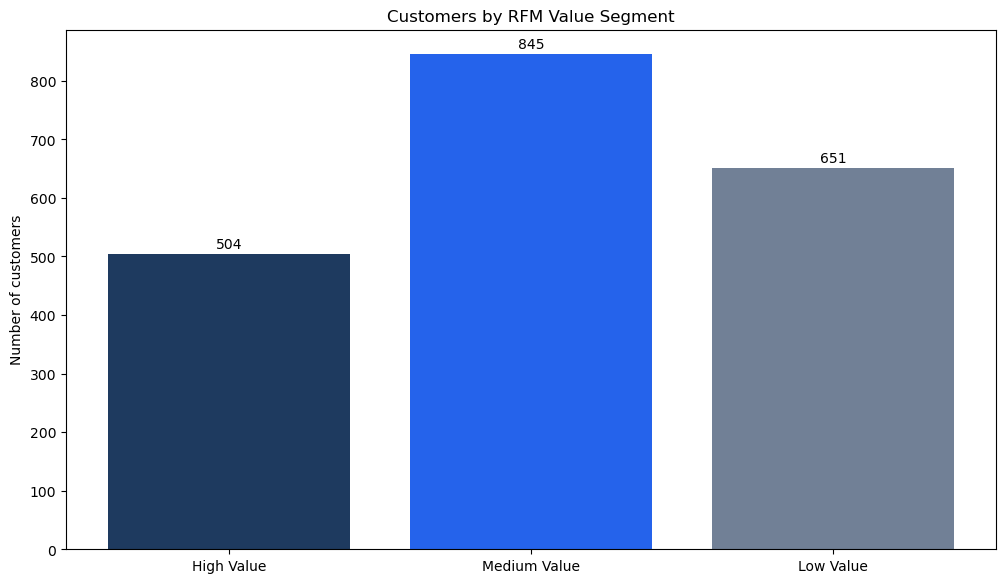

Saved ../exports/module2/value_segment_counts.png


In [8]:
fig, ax = plt.subplots(figsize=FIG_SIZE)
counts = rfm['value_segment'].value_counts().reindex(['High Value', 'Medium Value', 'Low Value'])
ax.bar(counts.index, counts.values, color=[NAVY, BLUE, SLATE])
ax.set_ylabel('Number of customers')
ax.set_title('Customers by RFM Value Segment')
for i, v in enumerate(counts.values):
    ax.text(i, v + 10, f'{v:,}', ha='center')
plt.show()
save_fig(fig, 'value_segment_counts.png')

In [9]:
biz_segment = df.groupby('customer_id')['segment'].first().reset_index()
rfm = rfm.merge(biz_segment, on='customer_id')

crosstab = pd.crosstab(rfm['value_segment'], rfm['segment'])
crosstab

segment,Budget,New,Premium,Standard
value_segment,,,,
High Value,131,75,73,225
Low Value,163,98,102,288
Medium Value,207,119,128,391


* A sizeable number of customers labelled
`Budget` or `Standard` in the business segment actually fall into `High Value`
on RFM (and vice versa for some `Premium` customers). This is a genuine
finding worth flagging in the report — the existing business label is not a
reliable proxy for actual purchase value, which is exactly why a
behaviour-based segmentation adds value on top of it.

## Cluster Analysis

### K-Means Clustering

The quintile-based tiers above use
fixed thresholds (12, 8) chosen by hand. Clustering instead lets the data
decide where the natural groupings are, based on the raw Recency, Frequency
and Monetary values (not the 1–5 scores).

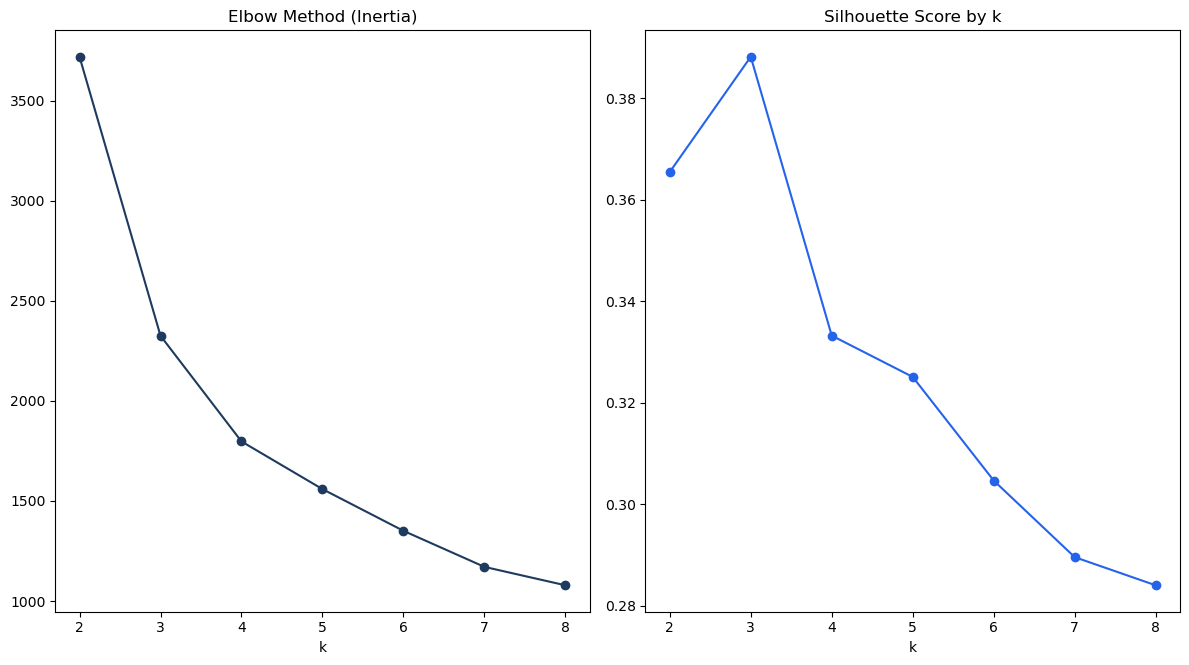

Saved ../exports/module2/kmeans_k_selection.png


,k,inertia,silhouette
0,2,"3,719.38",0.36
1,3,"2,325.34",0.39
2,4,"1,797.32",0.33
3,5,"1,559.18",0.33
4,6,"1,350.76",0.30
5,7,"1,170.71",0.29
6,8,"1,078.74",0.28


In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X = rfm[['recency', 'frequency', 'monetary']]
X_scaled = StandardScaler().fit_transform(X)

k_range = range(2, 9)
inertias, silhouettes = [], []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=FIG_SIZE)
axes[0].plot(list(k_range), inertias, marker='o', color=NAVY)
axes[0].set_title('Elbow Method (Inertia)')
axes[0].set_xlabel('k')
axes[1].plot(list(k_range), silhouettes, marker='o', color=BLUE)
axes[1].set_title('Silhouette Score by k')
axes[1].set_xlabel('k')
plt.tight_layout()
plt.show()
save_fig(fig, 'kmeans_k_selection.png')

pd.DataFrame({'k': list(k_range), 'inertia': inertias, 'silhouette': silhouettes}).round(3)

* The silhouette score is actually highest at k=3, which
statistically validates the 3-tier RFM segmentation above — the natural
structure in the data really is close to three groups. We select **k=4**
instead for the final model, because it still has an acceptable silhouette
score (~0.33, well above the 0.25 threshold generally considered reasonable)
and it separates out a distinct low-frequency, high-recency group that is
commercially useful to flag separately (an "at-risk" segment) — a case where
slightly more business granularity is worth a small drop in pure statistical
optimality. This trade-off is stated explicitly rather than silently
choosing whichever k looks best.

In [11]:
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['cluster'] = kmeans_final.fit_predict(X_scaled)

cluster_profile = rfm.groupby('cluster')[['recency', 'frequency', 'monetary']].mean().round(1)
cluster_profile['n_customers'] = rfm['cluster'].value_counts()
cluster_profile = cluster_profile.sort_values('monetary', ascending=False)
cluster_profile

,recency,frequency,monetary,n_customers
cluster,,,,
3,15.60,31.60,"14,072.40",376
0,18.40,27.10,"9,258.10",896
2,28.50,19.60,"6,355.90",614
1,209.10,15.90,"5,480.60",114


In [12]:
# Label clusters by their actual profile
cluster_labels = {}
sorted_by_monetary = cluster_profile.index.tolist()
label_names = ['Champions', 'Repeat Customers', 'Occasional', 'At Risk']

# The dormant group is identified by high recency, not just low monetary
dormant_cluster = cluster_profile['recency'].idxmax()
remaining = [c for c in sorted_by_monetary if c != dormant_cluster]

cluster_labels[remaining[0]] = 'Champions'
cluster_labels[remaining[1]] = 'Repeat Customers'
cluster_labels[remaining[2]] = 'Occasional'
cluster_labels[dormant_cluster] = 'At Risk'

rfm['cluster_label'] = rfm['cluster'].map(cluster_labels)
rfm['cluster_label'].value_counts()

cluster_label
Repeat Customers    896
Occasional          614
Champions           376
At Risk             114
Name: count, dtype: int64

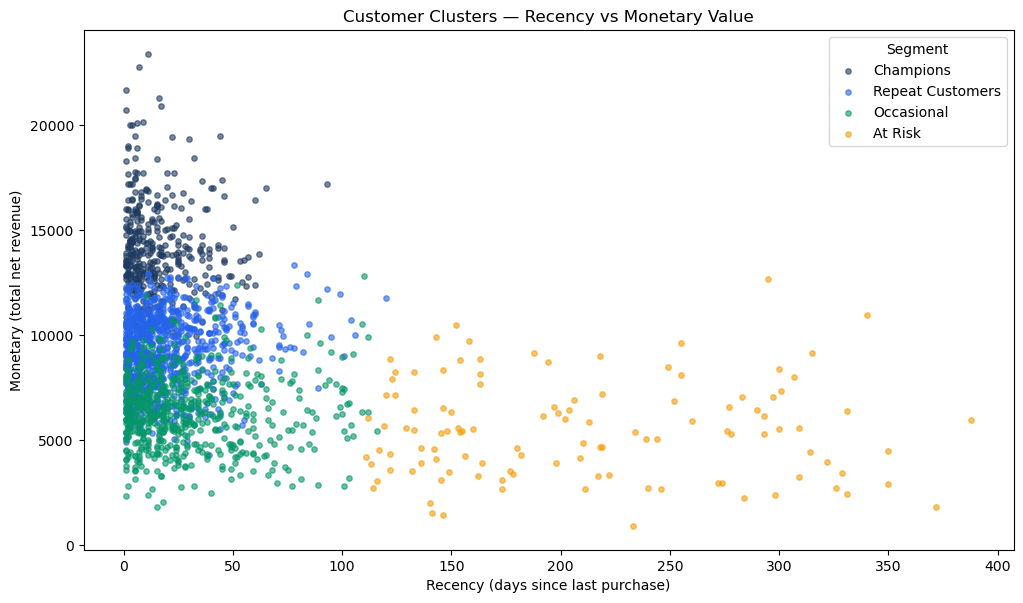

Saved ../exports/module2/kmeans_clusters_scatter.png


In [13]:
fig, ax = plt.subplots(figsize=FIG_SIZE)

cluster_colors = {'Champions': NAVY, 'Repeat Customers': BLUE, 'Occasional': '#059669', 'At Risk': AMBER}

for label, color in cluster_colors.items():
    subset = rfm[rfm['cluster_label'] == label]
    ax.scatter(subset['recency'], subset['monetary'], color=color, alpha=0.6, s=15, label=label)

ax.set_xlabel('Recency (days since last purchase)')
ax.set_ylabel('Monetary (total net revenue)')
ax.set_title('Customer Clusters — Recency vs Monetary Value')
ax.legend(title='Segment')
plt.show()
save_fig(fig, 'kmeans_clusters_scatter.png')

## Customer Lifetime Value (CLV) Estimate

```
CLV = Average Order Value × Purchase Frequency per Year × Assumed Lifespan (years)
```

**Assumption:** lifespan is set to 3 years. The dataset
only covers 2 years of actual transactions, so any lifespan figure is an
assumption, not an observed value — 3 years is used as a simple, round
planning horizon slightly beyond the observed data window.

In [14]:
LIFESPAN_YEARS = 3

customer_since = df.groupby('customer_id')['customer_since'].first()
rfm = rfm.merge(customer_since.rename('customer_since'), on='customer_id')

tenure_days = (df['transaction_date'].max() - rfm['customer_since']).dt.days
rfm['tenure_years'] = (tenure_days / 365.25).clip(lower=0.1)  # avoid divide-by-zero for brand new customers

rfm['avg_order_value'] = rfm['monetary'] / rfm['frequency']
rfm['purchases_per_year'] = rfm['frequency'] / rfm['tenure_years']
rfm['clv_estimate'] = rfm['avg_order_value'] * rfm['purchases_per_year'] * LIFESPAN_YEARS

rfm['clv_estimate'].describe().round(0)

count    2,000.00
mean    11,679.00
std      5,193.00
min      1,372.00
25%      7,847.00
50%     10,994.00
75%     14,768.00
max     38,649.00
Name: clv_estimate, dtype: float64

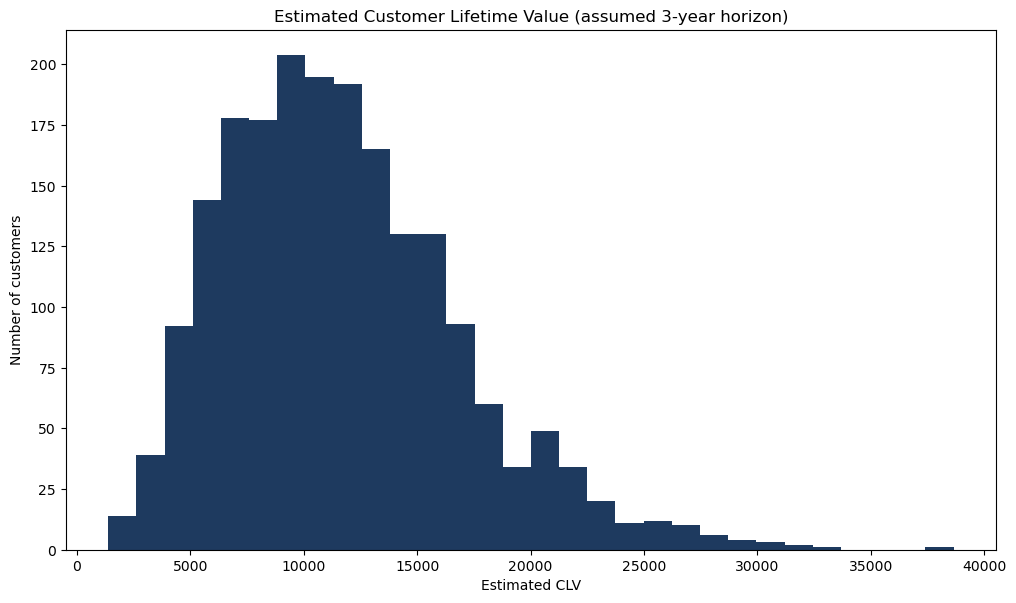

Saved ../exports/module2/clv_distribution.png


In [15]:
fig, ax = plt.subplots(figsize=FIG_SIZE)
ax.hist(rfm['clv_estimate'], bins=30, color=NAVY)
ax.set_xlabel('Estimated CLV')
ax.set_ylabel('Number of customers')
ax.set_title(f'Estimated Customer Lifetime Value (assumed {LIFESPAN_YEARS}-year horizon)')
plt.show()
save_fig(fig, 'clv_distribution.png')

## Repeat Purchase Behaviour & Inactive Customers

In [16]:
print('Minimum transactions per customer:', rfm['frequency'].min())
print('Repeat purchase rate (>1 transaction):', round((rfm['frequency'] > 1).mean() * 100, 1), '%')

Minimum transactions per customer: 6
Repeat purchase rate (>1 transaction): 100.0 %


**Repeat purchase rate:** note that in this dataset every customer already
has at least 6 transactions (`rfm['frequency'].min()` below), so a simple
"bought more than once" flag is not informative here.

**Inactive customers:** defined as customers whose Recency exceeds 90 days.
This threshold is chosen relative to the data itself — with a median
purchase gap (16 days) this small, 90 days without a purchase is a meaningful drop-off,
not an arbitrary number.

In [17]:
INACTIVE_THRESHOLD_DAYS = 90
rfm['is_inactive'] = rfm['recency'] > INACTIVE_THRESHOLD_DAYS

n_inactive = rfm['is_inactive'].sum()
pct_inactive = rfm['is_inactive'].mean() * 100
revenue_at_risk = rfm.loc[rfm['is_inactive'], 'monetary'].sum()

print(f"Inactive customers (> {INACTIVE_THRESHOLD_DAYS} days): {n_inactive} ({pct_inactive:.1f}%)")
print(f"Historical revenue tied to inactive customers: {revenue_at_risk:,.0f}")

Inactive customers (> 90 days): 148 (7.4%)
Historical revenue tied to inactive customers: 901,341


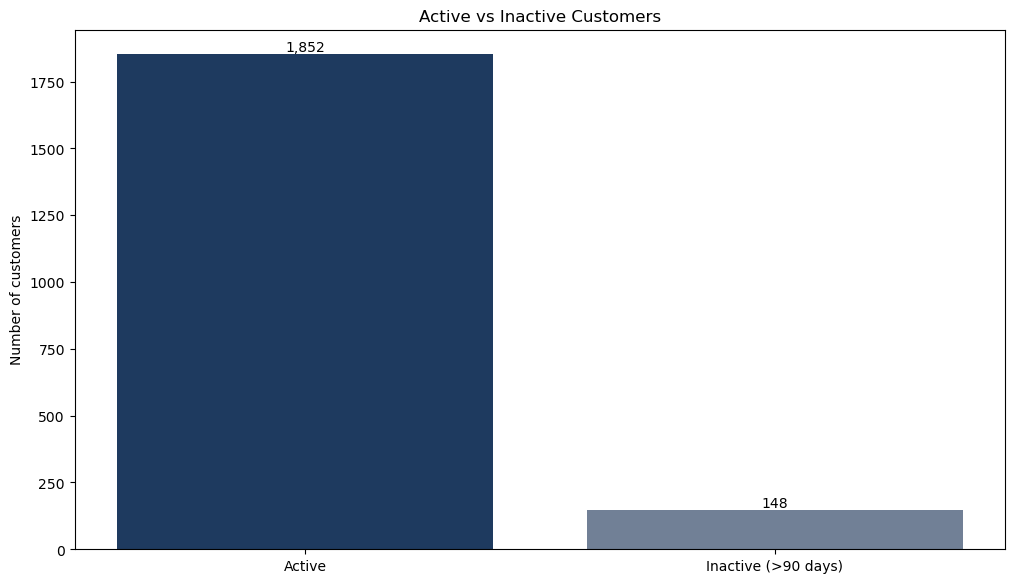

Saved ../exports/module2/active_vs_inactive.png


In [18]:
fig, ax = plt.subplots(figsize=FIG_SIZE)
status_counts = rfm['is_inactive'].map({True: 'Inactive (>90 days)', False: 'Active'}).value_counts()
ax.bar(status_counts.index, status_counts.values, color=[NAVY, SLATE])
ax.set_ylabel('Number of customers')
ax.set_title('Active vs Inactive Customers')
for i, v in enumerate(status_counts.values):
    ax.text(i, v + 10, f'{v:,}', ha='center')
plt.show()
save_fig(fig, 'active_vs_inactive.png')

## Top Customers & Revenue Concentration

Rank customers by total net revenue (Monetary) and check what
share of total revenue the top decile contributes. This is the customer-level
equivalent of the Pareto analysis already done at the product level in
Module 3 — it tells management how dependent the business is on a small
group of customers.

In [19]:
top10_customers = rfm.sort_values('monetary', ascending=False).head(10)[
    ['customer_id', 'recency', 'frequency', 'monetary', 'value_segment', 'cluster_label']
]
top10_customers

,customer_id,recency,frequency,monetary,value_segment,cluster_label
1283,C01284,11,32,"23,400.90",High Value,Champions
133,C00134,7,37,"22,750.37",High Value,Champions
1018,C01019,1,28,"21,665.72",High Value,Champions
230,C00231,16,42,"21,269.99",High Value,Champions
1131,C01132,17,34,"20,894.44",High Value,Champions
1968,C01969,1,36,"20,733.87",High Value,Champions
1732,C01733,9,31,"20,157.01",High Value,Champions
78,C00079,6,30,"20,081.06",High Value,Champions
1157,C01158,3,27,"19,992.51",High Value,Champions
928,C00929,4,43,"19,982.56",High Value,Champions


In [20]:
rfm_sorted = rfm.sort_values('monetary', ascending=False).reset_index(drop=True)
total_revenue = rfm_sorted['monetary'].sum()

top10pct_n = int(len(rfm_sorted) * 0.10)
top20pct_n = int(len(rfm_sorted) * 0.20)

share_top10pct = rfm_sorted.head(top10pct_n)['monetary'].sum() / total_revenue * 100
share_top20pct = rfm_sorted.head(top20pct_n)['monetary'].sum() / total_revenue * 100

print(f"Top 10% of customers ({top10pct_n} customers) contribute {share_top10pct:.1f}% of total revenue")
print(f"Top 20% of customers ({top20pct_n} customers) contribute {share_top20pct:.1f}% of total revenue")

Top 10% of customers (200 customers) contribute 17.3% of total revenue
Top 20% of customers (400 customers) contribute 31.2% of total revenue


* Revenue is fairly evenly spread across the customer
base (top 10% of customers contribute well under half of total revenue),
unlike a classic 80/20 pattern. This is a useful, non-obvious finding — it means the business is not overly dependent on a small handful of
customers, which is a different risk profile from the product-level
concentration found in Module 3.

In [21]:
summary_export = {
    'n_customers': int(len(rfm)),
    'value_segment_counts': rfm['value_segment'].value_counts().to_dict(),
    'cluster_labels': rfm['cluster_label'].value_counts().to_dict(),
    'silhouette_by_k': dict(zip(k_range, [round(s, 3) for s in silhouettes])),
    'chosen_k': 4,
    'clv_lifespan_years': LIFESPAN_YEARS,
    'clv_median': float(rfm['clv_estimate'].median()),
    'inactive_threshold_days': INACTIVE_THRESHOLD_DAYS,
    'n_inactive': int(n_inactive),
    'pct_inactive': round(float(pct_inactive), 2),
    'revenue_at_risk': float(revenue_at_risk),
    'top10pct_revenue_share': round(float(share_top10pct), 2),
    'top20pct_revenue_share': round(float(share_top20pct), 2),
}
save_json(summary_export, 'module2_summary.json')
rfm.to_csv(f'{EXPORT_DIR}/customer_rfm_segments.csv', index=False)
print(f"Saved {EXPORT_DIR}/customer_rfm_segments.csv")

Saved ../exports/module2/module2_summary.json
Saved ../exports/module2/customer_rfm_segments.csv
